## Dissertation Notebook 01A

# Derm7pt: Dataset Check and Target Preparation

**Author:** Garry Da Costa  
**Supervisor:** Dr Deblina Bhattacharjee

**Month:** September 2026  

---

## Introduction

This notebook checks the Derm7pt dataset before it is used for multi-task training.

The metadata and dataset splits are checked first. The seven checklist labels are then checked, grouped and encoded for the model. The dermoscopic image files are checked in the final section.

Grouped checklist labels follow the Derm7pt preprocessing code from Kawahara et al. (2019).

## Setup

### Getting the data

Derm7pt is described by Kawahara et al. (2019). The dataset contains metadata, diagnosis labels, seven checklist labels, and clinical and dermoscopic images.

The dataset was downloaded earlier and stored in Google Drive.

The folder used here is:

```text
release_v0/
├── images/
├── meta/
│   ├── meta.csv
│   ├── train_indexes.csv
│   ├── valid_indexes.csv
│   └── test_indexes.csv
└── ...

In [107]:
#1
##
## Imports
##

import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import PIL
from PIL import Image

In [108]:
#2
##
## Software versions
##

print("=" * 67)
print(f"{'Software versions':^67}")
print("=" * 67, "\n")

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"Pillow: {PIL.__version__}")

                         Software versions                         

Python: 3.13.15
pandas: 2.2.3
matplotlib: 3.10.0
Pillow: 11.3.0


In [109]:

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [110]:
#3
##
## Dataset paths
##

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation_Data")
DERM7PT_ROOT = PROJECT_ROOT / "Derm7pt"

DATA_DIR = DERM7PT_ROOT / "release_v0"
META_DIR = DATA_DIR / "meta"
IMG_DIR = DATA_DIR / "images"

META_CSV = META_DIR / "meta.csv"
TRAIN_INDEXES = META_DIR / "train_indexes.csv"
VALID_INDEXES = META_DIR / "valid_indexes.csv"
TEST_INDEXES = META_DIR / "test_indexes.csv"

required_paths = [
    DATA_DIR,
    META_DIR,
    IMG_DIR,
    META_CSV,
    TRAIN_INDEXES,
    VALID_INDEXES,
    TEST_INDEXES
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

print("=" * 67)
print(f"{'Derm7pt paths':^67}")
print("=" * 67, "\n")

print("Dataset root:", DERM7PT_ROOT)
print("Data:", DATA_DIR)
print("Metadata:", META_CSV)
print("Images:", IMG_DIR)
print("Train indexes:", TRAIN_INDEXES)
print("Validation indexes:", VALID_INDEXES)
print("Test indexes:", TEST_INDEXES)

print(f"\nPaths checked: {len(required_paths)}")
print(f"Missing paths: {len(missing_paths)}")

if missing_paths:
    raise FileNotFoundError(
        "Missing files:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

                           Derm7pt paths                           

Dataset root: /content/drive/MyDrive/Dissertation_Data/Derm7pt
Data: /content/drive/MyDrive/Dissertation_Data/Derm7pt/release_v0
Metadata: /content/drive/MyDrive/Dissertation_Data/Derm7pt/release_v0/meta/meta.csv
Images: /content/drive/MyDrive/Dissertation_Data/Derm7pt/release_v0/images
Train indexes: /content/drive/MyDrive/Dissertation_Data/Derm7pt/release_v0/meta/train_indexes.csv
Validation indexes: /content/drive/MyDrive/Dissertation_Data/Derm7pt/release_v0/meta/valid_indexes.csv
Test indexes: /content/drive/MyDrive/Dissertation_Data/Derm7pt/release_v0/meta/test_indexes.csv

Paths checked: 7
Missing paths: 0


## Section 1: Metadata

`meta.csv` is loaded and its basic structure is checked.

In [111]:
##
## Load and inspect metadata
##

meta_df = pd.read_csv(META_CSV)

if len(meta_df) != 1011:
    raise ValueError(
        f"Expected 1,011 records, found {len(meta_df):}."
    )
print("=" * 67)
print(f"{'Derm7pt metadata':^67}")
print("=" * 67, "\n")

print(f"\nRows   : {meta_df.shape[0]:,}")
print(f"\nColumns: {meta_df.shape[1]}")

column_info = pd.DataFrame({
    "column": meta_df.columns,
    "dtype": meta_df.dtypes.astype(str).values
})
print("\nColumn information")
display(column_info)
print("\nFirst ten rows")
display(meta_df.head(10))

                         Derm7pt metadata                          


Rows   : 1,011

Columns: 19

Column information


,column,dtype
0,case_num,int64
1,diagnosis,object
2,seven_point_score,int64
3,pigment_network,object
4,streaks,object
5,pigmentation,object
6,regression_structures,object
7,dots_and_globules,object
8,blue_whitish_veil,object
9,vascular_structures,object



First ten rows


,case_num,diagnosis,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,level_of_diagnostic_difficulty,elevation,location,sex,management,clinic,derm,case_id,notes
0,1,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,medium,nodular,abdomen,female,excision,NEL/NEL025.JPG,NEL/Nel026.jpg,NaN,NaN
1,2,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,absent,low,palpable,head neck,female,excision,NEL/NEL027.JPG,NEL/Nel028.jpg,NaN,NaN
2,3,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,arborizing,medium,palpable,head neck,female,excision,NEL/Nel032.jpg,NEL/Nel033.jpg,NaN,NaN
3,4,basal cell carcinoma,4,absent,absent,absent,blue areas,irregular,present,within regression,low,palpable,lower limbs,male,excision,NEL/NEL034.JPG,NEL/Nel035.jpg,NaN,NaN
4,5,basal cell carcinoma,1,absent,absent,diffuse irregular,absent,absent,absent,absent,high,palpable,upper limbs,female,excision,NEL/NEL036.JPG,NEL/Nel037.jpg,NaN,NaN
5,6,basal cell carcinoma,1,absent,absent,diffuse irregular,absent,absent,absent,absent,high,palpable,head neck,female,excision,NEL/Nel038.jpg,NEL/Nel039.jpg,NaN,NaN
6,7,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,high,nodular,back,male,excision,NEL/Nel040.jpg,NEL/Nel041.jpg,NaN,NaN
7,8,basal cell carcinoma,4,absent,absent,diffuse irregular,absent,irregular,present,absent,high,nodular,head neck,male,excision,NEL/Nel084.jpg,NEL/Nel085.jpg,NaN,NaN
8,9,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,low,nodular,back,female,excision,NEL/Nel086.jpg,NEL/Nel087.jpg,NaN,NaN
9,10,basal cell carcinoma,2,absent,absent,diffuse irregular,absent,irregular,absent,arborizing,low,palpable,head neck,female,excision,NEL/NEL088.JPG,NEL/Nel089.jpg,NaN,NaN


## Section 2: Official dataset partitions

Derm7pt provides fixed train, validation and test index files. Their coverage and separation are checked before they are reused in later experiments.

In [112]:
##
## Check split integrity
##

train_idx = pd.read_csv(TRAIN_INDEXES).iloc[:, 0].tolist()
valid_idx = pd.read_csv(VALID_INDEXES).iloc[:, 0].tolist()
test_idx = pd.read_csv(TEST_INDEXES).iloc[:, 0].tolist()

train_set = set(train_idx)
valid_set = set(valid_idx)
test_set = set(test_idx)

train_valid_overlap = len(train_set & valid_set)
train_test_overlap = len(train_set & test_set)
valid_test_overlap = len(valid_set & test_set)

overlap = (
    train_valid_overlap
    + train_test_overlap
    + valid_test_overlap
)

all_idx = train_idx + valid_idx + test_idx

missing = set(meta_df.index) - set(all_idx)
extra = set(all_idx) - set(meta_df.index)

coverage_complete = (
    len(missing) == 0
    and len(extra) == 0
    and len(all_idx) == len(meta_df)
)

if overlap > 0:
    raise ValueError("Split overlap detected.")

if not coverage_complete:
    raise ValueError("Split coverage is incomplete.")


print("=" * 67)
print(f"{'Derm7pt dataset partitions':^67}")
print("=" * 67, "\n")

print(f"Training split: {len(train_idx)}")
print(f"Validation split: {len(valid_idx)}")
print(f"Test split: {len(test_idx)}")
print(f"Total rows: {len(all_idx)}")
print(f"Overlap: {overlap}")
print(f"Missing rows: {len(missing)}")
print(f"Extra rows: {len(extra)}")

                    Derm7pt dataset partitions                     

Training split: 413
Validation split: 203
Test split: 395
Total rows: 1011
Overlap: 0
Missing rows: 0
Extra rows: 0


## Section 3: Derm7pt diagnosis labels

The Derm7pt diagnosis labels are checked before the checklist labels.

The class counts and percentages are shown, followed by a visual check of the distribution.


### 3.1 Diagnosis distribution

The number and percentage of cases in each diagnosis class are shown below.



In [113]:
##
## Diagnosis distribution
##

DIAG_COL = "diagnosis"

if DIAG_COL not in meta_df.columns:
    raise KeyError("Diagnosis column not found.")

diagnosis_distribution = pd.DataFrame({
    "Count": meta_df[DIAG_COL].value_counts(),
    "Percentage": (
        meta_df[DIAG_COL]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})


print("=" * 67)
print(f"{'Derm7pt diagnosis distribution':^67}")
print("=" * 67, "\n")

display(diagnosis_distribution)




                  Derm7pt diagnosis distribution                   



,Count,Percentage
diagnosis,,
clark nevus,399,39.47
melanoma (less than 0.76 mm),102,10.09
reed or spitz nevus,79,7.81
melanoma (in situ),64,6.33
melanoma (0.76 to 1.5 mm),53,5.24
seborrheic keratosis,45,4.45
basal cell carcinoma,42,4.15
dermal nevus,33,3.26
vascular lesion,29,2.87


### 3.2 Diagnosis checks

The number of classes, missing values and difference between the largest and smallest classes are checked.

In [114]:


##
## Check diagnosis labels
##

number_of_classes = len(diagnosis_distribution)

missing_diagnosis = meta_df[DIAG_COL].isna().sum()

max_min_ratio = (
    diagnosis_distribution["Count"].max()
    / diagnosis_distribution["Count"].min()
)


print(f"Number of diagnosis classes: {number_of_classes}")
print(f"Missing diagnosis values: {missing_diagnosis}")
print(f"Max/min class ratio: {max_min_ratio:.1f} x")


if missing_diagnosis > 0:
    raise ValueError("Missing diagnosis values found.")




Number of diagnosis classes: 20
Missing diagnosis values: 0
Max/min class ratio: 399.0 x


### 3.2 Grouped diagnosis labels

The Derm7pt repository groups the original diagnosis labels into five broader diagnosis groups: basal cell carcinoma (BCC), naevus (NEV), melanoma (MEL), miscellaneous (MISC) and seborrhoeic keratosis (SK).

These groups are retained for later comparison with the primary ISIC diagnostic target during external diagnostic evaluation.

In [115]:

DERM7PT_DIAGNOSIS_GROUPS = {
    "basal cell carcinoma": "BCC",

    "clark nevus": "NEV",
    "reed or spitz nevus": "NEV",
    "dermal nevus": "NEV",
    "blue nevus": "NEV",
    "congenital nevus": "NEV",
    "combined nevus": "NEV",
    "recurrent nevus": "NEV",

    "melanoma": "MEL",
    "melanoma (in situ)": "MEL",
    "melanoma (less than 0.76 mm)": "MEL",
    "melanoma (0.76 to 1.5 mm)": "MEL",
    "melanoma (more than 1.5 mm)": "MEL",
    "melanoma metastasis": "MEL",

    "seborrheic keratosis": "SK",

    "vascular lesion": "MISC",
    "lentigo": "MISC",
    "dermatofibroma": "MISC",
    "melanosis": "MISC",
    "miscellaneous": "MISC",
}

raw_diagnoses = set(meta_df["diagnosis"].dropna().unique())
mapped_diagnoses = set(DERM7PT_DIAGNOSIS_GROUPS)

if raw_diagnoses != mapped_diagnoses:
    raise ValueError(
        f"Diagnosis mapping mismatch. "
        f"Unmapped: {sorted(raw_diagnoses - mapped_diagnoses)}, "
        f"Unused: {sorted(mapped_diagnoses - raw_diagnoses)}"
    )

diagnosis_group = meta_df["diagnosis"].map(DERM7PT_DIAGNOSIS_GROUPS)

grouped_diagnosis_distribution = (
    diagnosis_group
    .value_counts()
    .rename_axis("Group")
    .reset_index(name="Count")
)

grouped_diagnosis_distribution["Percentage"] = (
    grouped_diagnosis_distribution["Count"] / len(meta_df) * 100
).round(2)

display(grouped_diagnosis_distribution)

,Group,Count,Percentage
0,NEV,575,56.87
1,MEL,252,24.93
2,MISC,97,9.59
3,SK,45,4.45
4,BCC,42,4.15


### 3.4 Diagnosis class distribution

The diagnosis class counts are plotted to show the difference in class sizes.

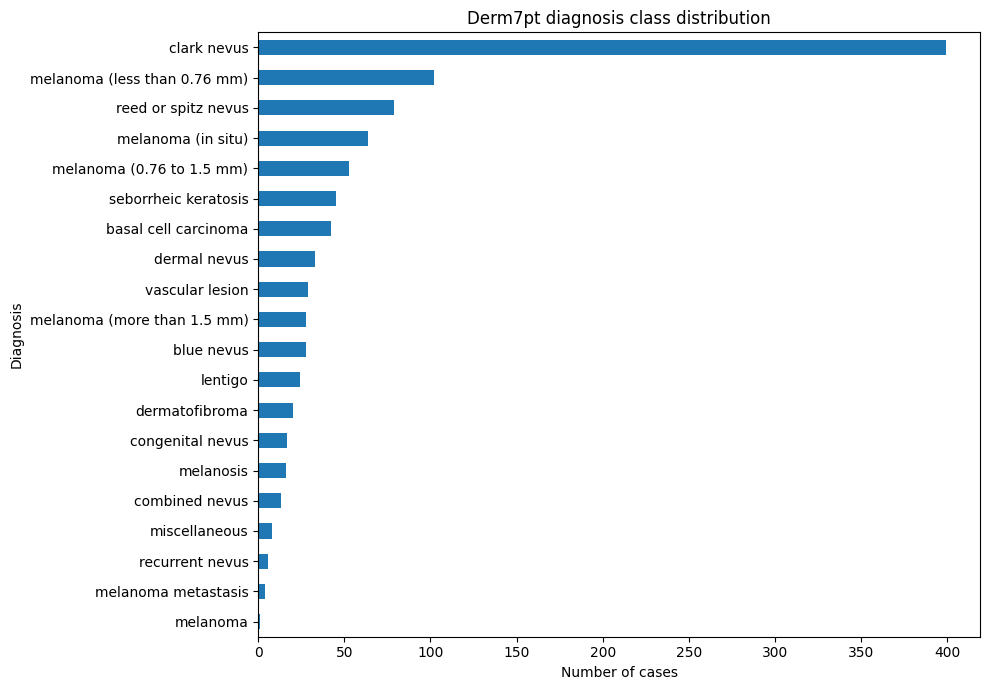

In [116]:
## Plot diagnosis class counts

plt.figure(figsize=(10, 7))

diagnosis_distribution['Count'].sort_values().plot(
    kind='barh'
)

plt.xlabel('Number of cases')
plt.ylabel('Diagnosis')
plt.title('Derm7pt diagnosis class distribution')
plt.tight_layout()
plt.show()

### 3.5 Melanoma vs naevus

Melanoma and naevus cases are checked separately because this boundary is important for the later diagnostic error analysis.

The counts are taken from the original Derm7pt diagnosis labels.

In [117]:

##
## Melanoma versus naevus counts
##

diagnosis_labels = meta_df[DIAG_COL].astype("string")

mel_mask = diagnosis_labels.str.contains(
    r"\bmelanoma\b",
    case=False,
    na=False,
    regex=True
)

nevus_mask = diagnosis_labels.str.contains(
    r"\bnevus\b",
    case=False,
    na=False,
    regex=True
)

n_melanoma = mel_mask.sum()
n_nevus = nevus_mask.sum()

overlap = (mel_mask & nevus_mask).sum()


print("=" * 67)
print(f"{'Melanoma versus naevus':^67}")
print("=" * 67, "\n")

print(f"Melanoma rows: {n_melanoma}")
print(f"Naevus rows: {n_nevus}")
print(f"Melanoma/naevus ratio: {n_melanoma / n_nevus:.2f}")


if n_melanoma == 0:
    raise ValueError(
        "No melanoma rows were found in the diagnosis labels."
    )

if n_nevus == 0:
    raise ValueError(
        "No naevus rows were found in the diagnosis labels."
    )

if overlap > 0:
    raise ValueError(
        f"{overlap} rows were assigned to both melanoma and naevus."
    )

                      Melanoma versus naevus                       

Melanoma rows: 252
Naevus rows: 575
Melanoma/naevus ratio: 0.44


## Section 4: Seven-point checklist labels

The seven checklist labels are used as auxiliary targets in the multi-task model.

Their availability, missing values and class distributions are checked before the labels are grouped and encoded for training.



### 4.1 Raw checklist labels

The seven checklist columns are checked for missing values and class counts.


In [118]:
##
## Check checklist labels
##

attribute_cols = [
    "pigment_network",
    "blue_whitish_veil",
    "vascular_structures",
    "pigmentation",
    "streaks",
    "dots_and_globules",
    "regression_structures"
]

missing_columns = [
    col for col in attribute_cols
    if col not in meta_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing checklist columns: {missing_columns}"
    )


print("=" * 67)
print(f"{'Derm7pt checklist labels':^67}")
print("=" * 67, "\n")

print(f"Checklist columns: {len(attribute_cols)}")
print(f"Missing columns: {len(missing_columns)}")

for attribute in attribute_cols:

    print(f"\n{attribute}")
    print(f"Missing labels: {meta_df[attribute].isna().sum()}")
    print(meta_df[attribute].value_counts())


total_missing = meta_df[attribute_cols].isna().sum().sum()

print(f"\nTotal missing labels: {total_missing}")

if total_missing > 0:
    raise ValueError("Missing checklist labels found.")

                     Derm7pt checklist labels                      

Checklist columns: 7
Missing columns: 0

pigment_network
Missing labels: 0
pigment_network
absent      400
typical     381
atypical    230
Name: count, dtype: int64

blue_whitish_veil
Missing labels: 0
blue_whitish_veil
absent     816
present    195
Name: count, dtype: int64

vascular_structures
Missing labels: 0
vascular_structures
absent               823
dotted                53
within regression     46
arborizing            31
comma                 23
linear irregular      18
hairpin               15
wreath                 2
Name: count, dtype: int64

pigmentation
Missing labels: 0
pigmentation
absent                 588
diffuse irregular      265
diffuse regular        115
localized irregular     40
localized regular        3
Name: count, dtype: int64

streaks
Missing labels: 0
streaks
absent       653
irregular    251
regular      107
Name: count, dtype: int64

dots_and_globules
Missing labels: 0
dots_and_globul

### 4.2 Small raw classes across splits

The smaller raw classes in `vascular_structures` and `pigmentation` are checked across the dataset splits.

In [119]:
##
## Check smaller raw classes by split
##

check_attributes = [
    "vascular_structures",
    "pigmentation"
]

split_indices = {
    "Training": train_idx,
    "Validation": valid_idx,
    "Test": test_idx
}


print("=" * 67)
print(f"{'Raw classes by dataset split':^67}")
print("=" * 67)

for attribute in check_attributes:

    print(f"\n{attribute}")

    for split_name, split_idx in split_indices.items():

        print(f"\n{split_name} split")

        print(
            meta_df.loc[
                split_idx,
                attribute
            ].value_counts()
        )

                   Raw classes by dataset split                    

vascular_structures

Training split
vascular_structures
absent               347
dotted                18
within regression     18
arborizing            12
comma                  8
linear irregular       5
hairpin                4
wreath                 1
Name: count, dtype: int64

Validation split
vascular_structures
absent               163
dotted                13
within regression      8
arborizing             6
linear irregular       5
comma                  4
hairpin                3
wreath                 1
Name: count, dtype: int64

Test split
vascular_structures
absent               313
dotted                22
within regression     20
arborizing            13
comma                 11
linear irregular       8
hairpin                8
Name: count, dtype: int64

pigmentation

Training split
pigmentation
absent                 253
diffuse irregular      100
diffuse regular         44
localized irregular     16
N

### 4.3 Grouping and encoding

Some raw checklist classes are grouped before training. The grouping follows `Derm7PtDatasetGroupInfrequent` from the Derm7pt preprocessing code.

The original metadata labels are not changed.

In [120]:

##
## Group and encode checklist labels
##

target_classes = {
    "pigment_network": ["absent", "typical", "atypical"],
    "blue_whitish_veil": ["absent", "present"],
    "vascular_structures": ["absent", "regular", "irregular"],
    "pigmentation": ["absent", "regular", "irregular"],
    "streaks": ["absent", "regular", "irregular"],
    "dots_and_globules": ["absent", "regular", "irregular"],
    "regression_structures": ["absent", "present"]
}

label_maps = {
    "pigment_network": {
        "absent": "absent",
        "typical": "typical",
        "atypical": "atypical"
    },

    "blue_whitish_veil": {
        "absent": "absent",
        "present": "present"
    },

    "vascular_structures": {
        "absent": "absent",
        "regular": "regular",
        "arborizing": "regular",
        "comma": "regular",
        "hairpin": "regular",
        "within regression": "regular",
        "wreath": "regular",
        "dotted/irregular": "irregular",
        "dotted": "irregular",
        "linear irregular": "irregular"
    },

    "pigmentation": {
        "absent": "absent",
        "regular": "regular",
        "diffuse regular": "regular",
        "localized regular": "regular",
        "irregular": "irregular",
        "diffuse irregular": "irregular",
        "localized irregular": "irregular"
    },

    "streaks": {
        "absent": "absent",
        "regular": "regular",
        "irregular": "irregular"
    },

    "dots_and_globules": {
        "absent": "absent",
        "regular": "regular",
        "irregular": "irregular"
    },

    "regression_structures": {
        "absent": "absent",
        "present": "present",
        "blue areas": "present",
        "white areas": "present",
        "combinations": "present"
    }
}


grouped_targets = pd.DataFrame(index=meta_df.index)
encoded_targets = pd.DataFrame(index=meta_df.index)

for attribute in attribute_cols:

    labels = meta_df[attribute].str.strip().str.lower()

    unknown = set(labels.dropna().unique()) - set(label_maps[attribute])

    if unknown:
        raise ValueError(
            f"Unknown labels in {attribute}: {sorted(unknown)}"
        )

    grouped_targets[attribute] = labels.map(label_maps[attribute])

    if grouped_targets[attribute].isna().any():
        raise ValueError(
            f"Unmapped labels found in {attribute}."
        )

    encoding = {
        label: number
        for number, label in enumerate(target_classes[attribute])
    }

    encoded_targets[attribute] = (
        grouped_targets[attribute]
        .map(encoding)
        .astype("int64")
    )


print("=" * 67)
print(f"{'Checklist target classes':^67}")
print("=" * 67, "\n")

for attribute in target_classes:
    print(f"{attribute}: {target_classes[attribute]}")

print("\nFirst ten encoded rows")
display(encoded_targets.head(10))

                     Checklist target classes                      

pigment_network: ['absent', 'typical', 'atypical']
blue_whitish_veil: ['absent', 'present']
vascular_structures: ['absent', 'regular', 'irregular']
pigmentation: ['absent', 'regular', 'irregular']
streaks: ['absent', 'regular', 'irregular']
dots_and_globules: ['absent', 'regular', 'irregular']
regression_structures: ['absent', 'present']

First ten encoded rows


,pigment_network,blue_whitish_veil,vascular_structures,pigmentation,streaks,dots_and_globules,regression_structures
0,0,0,1,0,0,0,0
1,0,0,0,0,0,2,0
2,0,0,1,0,0,2,0
3,0,1,1,0,0,2,1
4,0,0,0,2,0,0,0
5,0,0,0,2,0,0,0
6,0,0,1,0,0,0,0
7,0,1,0,2,0,2,0
8,0,0,1,0,0,0,0
9,0,0,1,2,0,2,0


### 4.4 Auxiliary target class decisions

All seven checklist attributes have complete labels, but some raw classes contain very few cases.

For `vascular_structures`, `wreath`, `hairpin` and `linear irregular` have low counts, and `wreath` is not present in the test partition.

For `pigmentation`, `localized regular` has only 3 samples and is only present in the test partition.

`vascular_structures` and `pigmentation` are grouped into absent, regular and irregular. `regression_structures` is grouped into absent and present.

The original metadata labels are kept unchanged.


## Section 5: Dermoscopic images

The dermoscopic image references are checked before the images are used for training.



### 5.1 Referenced image files

The dermoscopic filenames in the metadata are checked against the image folder.



In [121]:

##
## Check dermoscopic image files
##

DERM_COLUMN = "derm"

if DERM_COLUMN not in meta_df.columns:
    raise KeyError("Dermoscopic image column not found.")

missing_filenames = meta_df[DERM_COLUMN].isna().sum()

missing_files = []

for filename in meta_df[DERM_COLUMN].dropna():

    image_path = IMG_DIR / str(filename)

    if not image_path.is_file():
        missing_files.append(filename)


print("=" * 67)
print(f"{'Derm7pt dermoscopic images':^67}")
print("=" * 67, "\n")

print(f"Rows checked: {len(meta_df)}")
print(f"Missing filenames: {missing_filenames}")
print(f"Missing image files: {len(missing_files)}")


if missing_filenames > 0:
    raise ValueError("Missing dermoscopic filenames found.")

if missing_files:
    raise FileNotFoundError("Missing dermoscopic image files found.")



                    Derm7pt dermoscopic images                     

Rows checked: 1011
Missing filenames: 0
Missing image files: 0


### 5.2 Sample images

A few dermoscopic images are displayed with their diagnosis labels.




                     Sample Dermoscopic Images                     



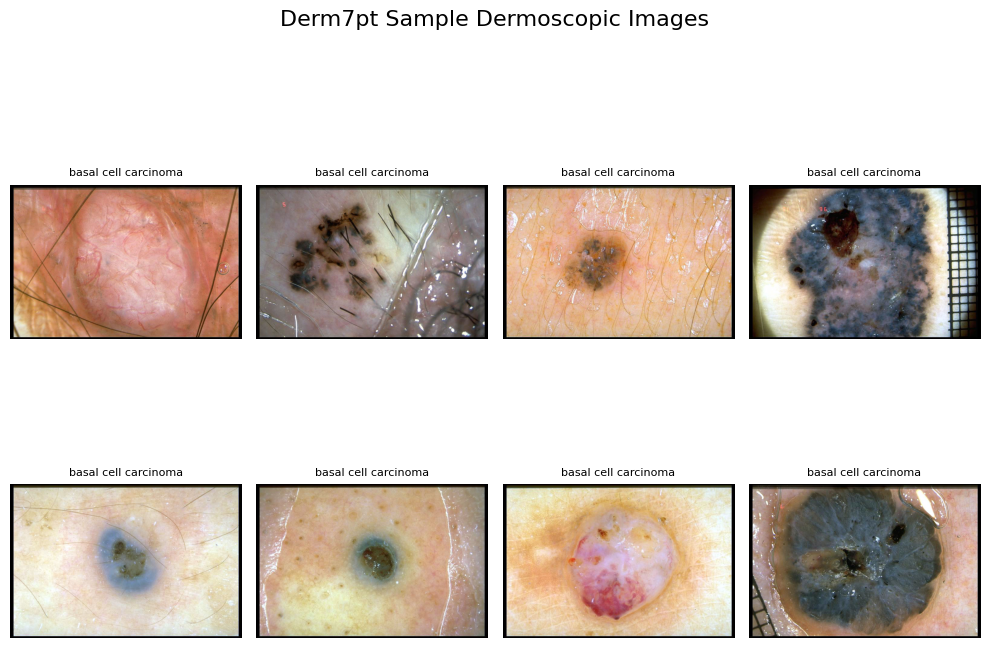

In [122]:


##
## Display sample dermoscopic images
##


print("=" * 130)
print(f"{'Sample Dermoscopic Images':^67}")
print("=" * 130, "\n")


sample = (
    meta_df
    .dropna(subset=[DERM_COLUMN])
    .head(8)
)

fig, axs = plt.subplots(2, 4, figsize=(10, 8))

for ax, (_, row) in zip(axs.flatten(), sample.iterrows()):

    image_path = IMG_DIR / str(row[DERM_COLUMN])

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(str(row[DIAG_COL]), fontsize=8)
    ax.axis('off')

fig.suptitle("Derm7pt Sample Dermoscopic Images", size=16)
plt.tight_layout()
plt.show()

## Section 6: Outputs and findings

The encoded auxiliary targets are saved for later modelling. The main findings from the Derm7pt checks are then summarised.



### 6.1 Save encoded targets

The encoded auxiliary targets are saved for later modelling.



In [123]:
##
## Save encoded targets
##

OUTPUT_DIR = DERM7PT_ROOT / "audit_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

targets_to_save = encoded_targets.copy()

targets_to_save.insert(
    0,
    "diagnosis_group",
    diagnosis_group
)

targets_to_save.insert(
    0,
    "diagnosis",
    meta_df["diagnosis"]
)

targets_to_save.insert(
    0,
    "metadata_index",
    meta_df.index
)

TARGETS_CSV = OUTPUT_DIR / "derm7pt_encoded_targets.csv"

targets_to_save.to_csv(
    TARGETS_CSV,
    index=False
)


print("=" * 67)
print(f"{'Derm7pt targets saved':^67}")
print("=" * 67, "\n")

print(f"Rows saved: {len(targets_to_save)}")
print(f"File: {TARGETS_CSV}")



                       Derm7pt targets saved                       

Rows saved: 1011
File: /content/drive/MyDrive/Dissertation_Data/Derm7pt/audit_outputs/derm7pt_encoded_targets.csv


### 6.2 Check saved targets

The saved file is loaded once to check the rows and missing values.


In [124]:
##
## Check saved targets
##

saved_targets = pd.read_csv(TARGETS_CSV)

print("=" * 67)
print(f"{'Check saved targets':^67}")
print("=" * 67, "\n")

print(f"Rows: {len(saved_targets)}")
print(f"Missing values: {saved_targets.isna().sum().sum()}")

display(saved_targets.head())


if len(saved_targets) != len(meta_df):
    raise ValueError("Saved row count does not match metadata.")

if saved_targets.isna().any().any():
    raise ValueError("Missing values found in saved targets.")





                        Check saved targets                        

Rows: 1011
Missing values: 0


,metadata_index,diagnosis,diagnosis_group,pigment_network,blue_whitish_veil,vascular_structures,pigmentation,streaks,dots_and_globules,regression_structures
0,0,basal cell carcinoma,BCC,0,0,1,0,0,0,0
1,1,basal cell carcinoma,BCC,0,0,0,0,0,2,0
2,2,basal cell carcinoma,BCC,0,0,1,0,0,2,0
3,3,basal cell carcinoma,BCC,0,1,1,0,0,2,1
4,4,basal cell carcinoma,BCC,0,0,0,2,0,0,0


### 6.3 Main findings

1. Derm7pt contains 1,011 records with 20 diagnosis labels. The dataset splits cover all records with no overlap.

2. The diagnosis labels are complete but unevenly distributed. There are 252 melanoma cases and 575 naevus cases, which will be considered in the later error analysis.

3. All seven checklist attributes have complete labels. The auxiliary target decisions are recorded in Section 4.4.

4. All referenced dermoscopic image files were found, and the sample images opened correctly.

5. The encoded auxiliary targets were saved for later modelling. The original dataset split files remain unchanged.


### 6.4 Next steps

The saved targets and fixed dataset splits will be used for modelling.

For later diagnostic evaluation, a partial grouping of the Derm7pt diagnoses into melanoma, naevus, basal cell carcinoma (BCC), seborrhoeic keratosis (SK) and other diagnoses will be considered.
